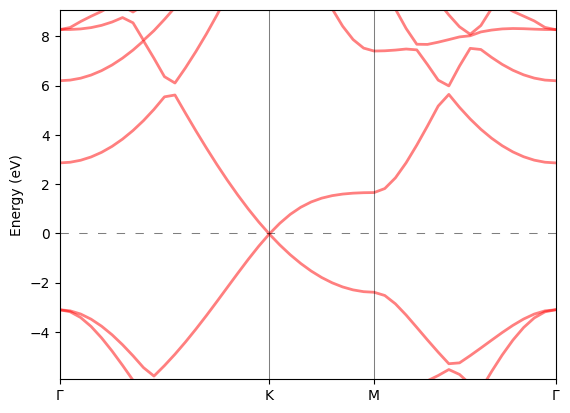

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('/content/graphene_bands.dat.gnu')

# Original k and energy
k = np.unique(data[:, 0])
energies = data[:, 1]

# Fermi level (original value)
EF = 0.921

# Shift the energies so that EF becomes 0
energies_shifted = energies - EF

# Reshape the shifted energies into band structure
bands = np.reshape(energies_shifted, (-1, len(k)))

# Plot
for band in range(len(bands)):
    plt.plot(k, bands[band, :], linewidth=2, alpha=0.5, color='r')

plt.xlim(min(k), max(k))
plt.ylim(-5-EF, 10-EF)  # update ylim if you want the same visual energy window

# new Fermi energy is 0
plt.axhline(0, linestyle=(0, (8, 10)), linewidth=0.75, color='k', alpha=0.5)

# High symmetry k-points
plt.axvline(0.6667, linewidth=0.75, color='k', alpha=0.5)
plt.axvline(1, linewidth=0.75, color='k', alpha=0.5)

plt.xticks(ticks=[0, 0.6667, 1, 1.5774], labels=['$\Gamma$', 'K', 'M', '$\Gamma$'])
plt.ylabel("Energy (eV)")
plt.show()


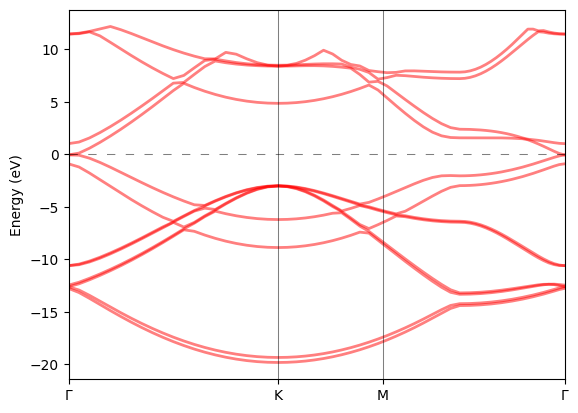

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- user inputs ---
fname = '/content/bands.dat.gnu'
fermi = 7.8043   # eV
# -------------------

data = np.loadtxt(fname)

# raw k and energy values
k_all = data[:, 0]
energies_raw = data[:, 1]

# shift energies so that EF = 0
energies = energies_raw - fermi

# detect segment breaks (k decreases → new path segment)
break_indices = np.where(np.diff(k_all) < 0)[0] + 1

# number of k-points in one segment (assumes all segments have equal length)
Nk = break_indices[0] if len(break_indices) > 0 else len(k_all)

# use the first Nk points as the k-vector
k = k_all[:Nk]

# reshape to (number_of_bands, Nk)
bands = energies.reshape(-1, Nk)

# plot all bands
for band in range(bands.shape[0]):
    plt.plot(k, bands[band, :], linewidth=2, alpha=0.5, color='r')

plt.xlim(min(k), 1.5774)

plt.ylabel("Energy (eV)")

# Fermi energy
plt.axhline(0, linestyle=(0, (8, 10)), linewidth=0.75, color='k', alpha=0.5)
plt.axvline(0.6667, linewidth=0.75, color='k', alpha=0.5)
plt.axvline(1, linewidth=0.75, color='k', alpha=0.5)

# you can add symmetry point markers manually if needed, e.g:
plt.xticks([0,0.6667,1,1.5774], ['Γ','K','M','Γ'])

plt.show()
